# Tahap 5 — Evaluasi Sistem Retrieval & Prediksi Solusi
### Sistem CBR Putusan Perceraian — Pengadilan Agama Kabupaten Malang

Notebook ini mengevaluasi performa **retrieval Top-K** (Accuracy, Precision, Recall, F1) dan **prediksi solusi** (klasifikasi berbobot) sistem CBR, dengan dukungan perbandingan antar model, visualisasi, confusion matrix, dan error analysis otomatis.

## 0. Persiapan Lingkungan & Struktur Folder

In [1]:
import ast
import glob
import json
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore")

In [2]:
BASE_DIR = "../data"
PATH_RESULTS_DIR = os.path.join(BASE_DIR, "results")
PATH_EVAL_DIR = os.path.join(BASE_DIR, "eval")
PATH_FIGURES_DIR = os.path.join(PATH_EVAL_DIR, "figures")
PATH_QUERIES_JSON = os.path.join(PATH_EVAL_DIR, "queries.json")

os.makedirs(PATH_EVAL_DIR, exist_ok=True)
os.makedirs(PATH_FIGURES_DIR, exist_ok=True)

K = 5  # kedalaman retrieval yang dievaluasi
print(f"BASE_DIR: {os.path.abspath(BASE_DIR)}")

BASE_DIR: e:\Kuliah\Semester - 6\Penalaran Komputer\Tugas-03\Backup\v03\cbr-putusan-perceraian\data


## 1. Fungsi Utilitas

Parsing daftar ID kasus yang fleksibel terhadap format (list literal, delimiter `;`/`,`), serta resolusi nama kolom agar notebook tetap berjalan meski skema `predictions.csv` / `queries.json` sedikit berbeda.

In [3]:
ID_LIST_COLS = ["top_5_case_ids", "retrieved_ids", "top_k_ids", "top_5_ids"]
PRED_COLS = ["predicted_solution", "prediction", "predicted_label"]
GT_KEYS = ["ground_truth", "relevant_cases", "relevant_ids"]
ACTUAL_KEYS = ["actual_solution", "label", "outcome"]


def parse_id_list(raw):
    if raw is None or (isinstance(raw, float) and pd.isna(raw)) or str(raw).strip() == "":
        return []
    raw_str = str(raw).strip()
    if raw_str.startswith("["):
        try:
            parsed = ast.literal_eval(raw_str)
            if isinstance(parsed, list):
                return [str(x).strip() for x in parsed]
        except (ValueError, SyntaxError):
            pass
    if ";" in raw_str:
        return [x.strip() for x in raw_str.split(";") if x.strip()]
    if "," in raw_str:
        return [x.strip() for x in raw_str.split(",") if x.strip()]
    return [raw_str]


def find_column(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

## 2. Pemuatan Data

Mendukung satu atau beberapa berkas prediksi (`predictions*.csv` di `data/results/`) untuk perbandingan antar model (mis. `predictions_tfidf.csv`, `predictions_svm.csv`). Jika hanya satu berkas tanpa kolom `model_name`, model diberi nama `baseline`.

In [4]:
def load_all_predictions(results_dir):
    files = sorted(glob.glob(os.path.join(results_dir, "predictions.csv")))
    if not files:
        raise FileNotFoundError(f"Tidak ada berkas predictions.csv pada '{results_dir}'")

    frames = []
    single_file = len(files) == 1
    for fp in files:
        df = pd.read_csv(fp, encoding="utf-8-sig")
        id_col = find_column(df, ID_LIST_COLS)
        pred_col = find_column(df, PRED_COLS)
        if id_col is None or pred_col is None or "query_id" not in df.columns:
            raise KeyError(f"Kolom wajib tidak ditemukan pada '{fp}'. Kolom tersedia: {list(df.columns)}")

        df = df.rename(columns={id_col: "retrieved_ids_raw", pred_col: "predicted_solution"})
        df["query_id"] = df["query_id"].astype(str).str.strip()
        df["retrieved_ids"] = df["retrieved_ids_raw"].apply(parse_id_list)
        df["predicted_solution"] = df["predicted_solution"].fillna("UNKNOWN").astype(str)

        if "model_name" not in df.columns:
            if single_file:
                df["model_name"] = "baseline"
            else:
                inferred = os.path.splitext(os.path.basename(fp))[0].replace("predictions", "").strip("_- ")
                df["model_name"] = inferred if inferred else "baseline"
        else:
            df["model_name"] = df["model_name"].fillna("baseline").astype(str).str.strip()

        keep_cols = ["query_id", "model_name", "predicted_solution", "retrieved_ids"]
        if "query" in df.columns:
            keep_cols.insert(1, "query")
        frames.append(df[keep_cols])

    return pd.concat(frames, ignore_index=True)


def load_queries(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Berkas queries tidak ditemukan: '{path}'")
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)

    query_map = {}
    for item in data:
        qid = str(item.get("query_id", "")).strip()
        gt_raw = next((item.get(k) for k in GT_KEYS if item.get(k)), [])
        actual_raw = next((item.get(k) for k in ACTUAL_KEYS if item.get(k)), None)
        query_map[qid] = {
            "ground_truth": [str(x).strip() for x in gt_raw],
            "actual_solution": str(actual_raw).strip() if actual_raw is not None else None,
        }
    return query_map

In [5]:
df_pred = load_all_predictions(PATH_RESULTS_DIR)
query_map = load_queries(PATH_QUERIES_JSON)
ground_truth = {qid: meta["ground_truth"] for qid, meta in query_map.items()}

print(f"Prediksi dimuat: {len(df_pred)} baris, model: {sorted(df_pred['model_name'].unique())}")
print(f"Query dengan metadata: {len(query_map)}")
df_pred.head()

Prediksi dimuat: 10 baris, model: ['baseline']
Query dengan metadata: 10


,query_id,query,model_name,predicted_solution,retrieved_ids
0,1,suami tidak memberikan nafkah kepada istri,baseline,Dikabulkan,[putusan_2513_pdt.g_2022_pa.kab.mlg_2026061708...
1,2,terjadi perselisihan dan pertengkaran terus me...,baseline,Dikabulkan,[putusan_6071_pdt.g_2022_pa.kab.mlg_2026061708...
2,3,suami meninggalkan rumah dan tidak memberi kabar,baseline,Dikabulkan,[putusan_5210_pdt.g_2022_pa.kab.mlg_2026061708...
3,4,hubungan rumah tangga tidak harmonis,baseline,Dikabulkan,[putusan_5280_pdt.g_2023_pa.kab.mlg_2026061708...
4,5,suami memiliki hubungan dengan perempuan lain,baseline,Dikabulkan,[putusan_1038_pdt.g_2017_pa.kab.mlg_2026061708...


## 3. Evaluasi Retrieval Top-K

Fungsi `eval_retrieval(queries, ground_truth, k)` menghitung Accuracy@K, Precision@K, Recall@K, dan F1@K **menggunakan `sklearn.metrics`** secara langsung — bukan kalkulasi manual. Untuk setiap query, dibentuk vektor relevansi biner atas gabungan ID yang ter-retrieve dan ID ground truth, lalu dihitung dengan `accuracy_score`, `precision_score`, `recall_score`, `f1_score`.

In [6]:
def eval_retrieval(queries, ground_truth, k):
    records = []
    for q in queries:
        qid = q["query_id"]
        model_name = q.get("model_name", "baseline")
        retrieved_k = list(q.get("retrieved_ids", []))[:k]
        gt = ground_truth.get(qid, [])

        universe = sorted(set(retrieved_k) | set(gt))
        if not universe:
            acc, prec, rec, f1, is_success = 0.0, 0.0, 0.0, 0.0, 0
        else:
            y_true = [1 if u in gt else 0 for u in universe]
            y_pred = [1 if u in retrieved_k else 0 for u in universe]
            acc = accuracy_score(y_true, y_pred)
            prec = precision_score(y_true, y_pred, zero_division=0)
            rec = recall_score(y_true, y_pred, zero_division=0)
            f1 = f1_score(y_true, y_pred, zero_division=0)
            is_success = int(any(t == 1 and p == 1 for t, p in zip(y_true, y_pred)))

        records.append({
            "query_id": qid,
            "model_name": model_name,
            "accuracy_at_k": round(acc, 4),
            "precision_at_k": round(prec, 4),
            "recall_at_k": round(rec, 4),
            "f1_at_k": round(f1, 4),
            "retrieved_ids": retrieved_k,
            "ground_truth_ids": gt,
            "is_success": is_success,
        })
    return pd.DataFrame(records)

In [7]:
queries_input = df_pred.to_dict("records")
df_retrieval = eval_retrieval(queries_input, ground_truth, K)

n_missing_gt = sum(1 for qid in df_retrieval["query_id"].unique() if not ground_truth.get(qid))
if n_missing_gt > 0:
    print(f"[PERINGATAN] {n_missing_gt} query tidak memiliki anotasi ground_truth -> metrik retrieval-nya 0.0.")

df_retrieval.head(10)

,query_id,model_name,accuracy_at_k,precision_at_k,recall_at_k,f1_at_k,retrieved_ids,ground_truth_ids,is_success
0,1,baseline,0.4,0.4,1.0,0.5714,[putusan_2513_pdt.g_2022_pa.kab.mlg_2026061708...,[putusan_2513_pdt.g_2022_pa.kab.mlg_2026061708...,1
1,2,baseline,0.2,0.2,1.0,0.3333,[putusan_6071_pdt.g_2022_pa.kab.mlg_2026061708...,[putusan_6071_pdt.g_2022_pa.kab.mlg_2026061708...,1
2,3,baseline,0.2,0.2,1.0,0.3333,[putusan_5210_pdt.g_2022_pa.kab.mlg_2026061708...,[putusan_5210_pdt.g_2022_pa.kab.mlg_2026061708...,1
3,4,baseline,0.2,0.2,1.0,0.3333,[putusan_5280_pdt.g_2023_pa.kab.mlg_2026061708...,[putusan_5280_pdt.g_2023_pa.kab.mlg_2026061708...,1
4,5,baseline,0.2,0.2,1.0,0.3333,[putusan_1038_pdt.g_2017_pa.kab.mlg_2026061708...,[putusan_1038_pdt.g_2017_pa.kab.mlg_2026061708...,1
5,6,baseline,0.2,0.2,1.0,0.3333,[putusan_7018_pdt.g_2022_pa.kab.mlg_2026061708...,[putusan_7018_pdt.g_2022_pa.kab.mlg_2026061708...,1
6,7,baseline,0.2,0.2,1.0,0.3333,[putusan_5657_pdt.g_2020_pa.kab.mlg_2026061708...,[putusan_5657_pdt.g_2020_pa.kab.mlg_2026061708...,1
7,8,baseline,0.2,0.2,1.0,0.3333,[putusan_7109_pdt.g_2022_pa.kab.mlg_2026061708...,[putusan_7109_pdt.g_2022_pa.kab.mlg_2026061708...,1
8,9,baseline,0.2,0.2,1.0,0.3333,[putusan_5280_pdt.g_2023_pa.kab.mlg_2026061708...,[putusan_5280_pdt.g_2023_pa.kab.mlg_2026061708...,1
9,10,baseline,0.2,0.2,1.0,0.3333,[putusan_2513_pdt.g_2022_pa.kab.mlg_2026061708...,[putusan_2513_pdt.g_2022_pa.kab.mlg_2026061708...,1


### 3.1 Ringkasan Rata-Rata Metrik Retrieval per Model

In [8]:
df_summary = (
    df_retrieval.groupby("model_name")[["accuracy_at_k", "precision_at_k", "recall_at_k", "f1_at_k"]]
    .mean().round(4).reset_index()
    .sort_values("f1_at_k", ascending=False)
)
df_summary

,model_name,accuracy_at_k,precision_at_k,recall_at_k,f1_at_k
0,baseline,0.22,0.22,1.0,0.3571


## 4. Evaluasi Prediksi Solusi (Klasifikasi Berbobot)

Menggunakan `sklearn.metrics` (`accuracy_score`, `precision_score`, `recall_score`, `f1_score` dengan `average="weighted"`). **Tidak ada fallback self-consistency** — jika `actual_solution` tidak tersedia untuk seluruh query suatu model, evaluasi model tersebut ditandai tidak valid (metrik `NaN`) beserta peringatan, bukan dipalsukan menjadi skor sempurna.

In [9]:
def eval_prediction(df_pred, query_map):
    rows = []
    cm_data = {}
    for model_name, group in df_pred.groupby("model_name"):
        y_true, y_pred = [], []
        missing = 0
        for _, row in group.iterrows():
            actual = query_map.get(row["query_id"], {}).get("actual_solution")
            if actual is None:
                missing += 1
                continue
            y_true.append(actual)
            y_pred.append(str(row["predicted_solution"]))

        if len(y_true) == 0:
            print(f"[PERINGATAN] Model '{model_name}': tidak ada 'actual_solution' valid pada queries.json.")
            print(f"             Evaluasi prediksi TIDAK VALID untuk model ini -> metrik diset NaN.")
            rows.append({
                "model_name": model_name, "accuracy": np.nan, "precision_weighted": np.nan,
                "recall_weighted": np.nan, "f1_weighted": np.nan, "support": 0,
                "evaluation_mode": "Invalid - Tanpa Ground Truth",
            })
            continue

        if missing > 0:
            print(f"[PERINGATAN] Model '{model_name}': {missing} query tanpa 'actual_solution' diabaikan.")

        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
        rec = recall_score(y_true, y_pred, average="weighted", zero_division=0)
        f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

        rows.append({
            "model_name": model_name, "accuracy": round(acc, 4),
            "precision_weighted": round(prec, 4), "recall_weighted": round(rec, 4),
            "f1_weighted": round(f1, 4), "support": len(y_true),
            "evaluation_mode": "Authentic",
        })
        cm_data[model_name] = (y_true, y_pred)

    return pd.DataFrame(rows), cm_data

In [10]:
df_prediction, cm_data = eval_prediction(df_pred, query_map)
df_prediction

,model_name,accuracy,precision_weighted,recall_weighted,f1_weighted,support,evaluation_mode
0,baseline,1.0,1.0,1.0,1.0,10,Authentic


### 4.1 Laporan Klasifikasi Per Kelas

In [11]:
for model_name, (yt, yp) in cm_data.items():
    labels = sorted(set(yt) | set(yp))
    print(f"=== Laporan Klasifikasi — Model: {model_name} ===")
    print(classification_report(yt, yp, labels=labels, zero_division=0))

=== Laporan Klasifikasi — Model: baseline ===
              precision    recall  f1-score   support

  Dikabulkan       1.00      1.00      1.00        10

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



## 5. Visualisasi Performa

### 5.1 Bar Chart — Metrik Retrieval per Model

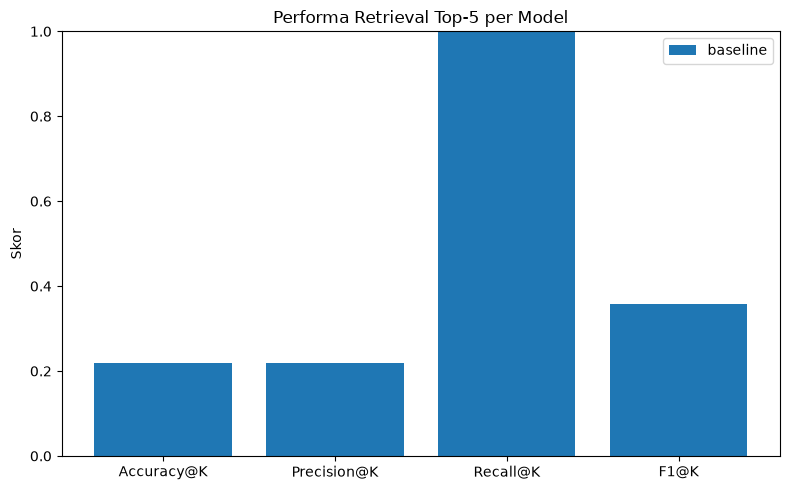

In [12]:
metrics_r = ["accuracy_at_k", "precision_at_k", "recall_at_k", "f1_at_k"]
labels_r = ["Accuracy@K", "Precision@K", "Recall@K", "F1@K"]
x = np.arange(len(metrics_r))
width = 0.8 / max(len(df_summary), 1)

fig, ax = plt.subplots(figsize=(8, 5))
for i, (_, row) in enumerate(df_summary.iterrows()):
    ax.bar(x + i * width, [row[m] for m in metrics_r], width, label=row["model_name"])
ax.set_xticks(x + width * (len(df_summary) - 1) / 2)
ax.set_xticklabels(labels_r)
ax.set_ylim(0, 1)
ax.set_ylabel("Skor")
ax.set_title(f"Performa Retrieval Top-{K} per Model")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(PATH_FIGURES_DIR, "retrieval_performance.png"), dpi=150)
plt.show()

### 5.2 Bar Chart — Metrik Prediksi Solusi per Model

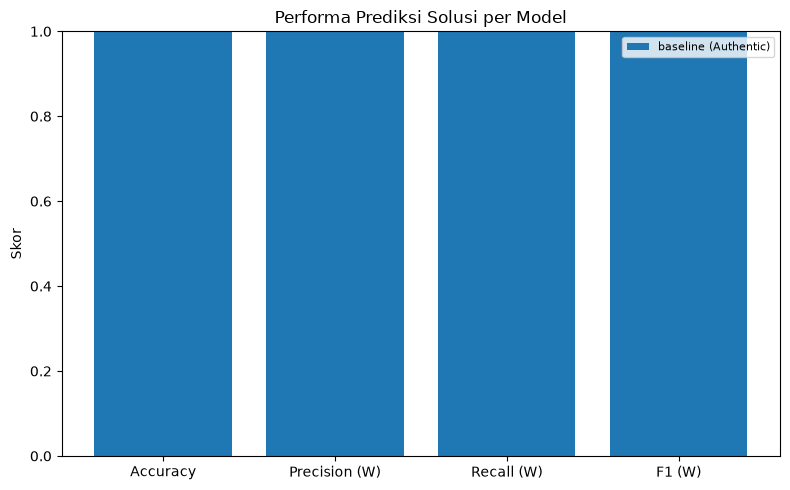

In [13]:
pred_metrics = ["accuracy", "precision_weighted", "recall_weighted", "f1_weighted"]
pred_labels = ["Accuracy", "Precision (W)", "Recall (W)", "F1 (W)"]
x2 = np.arange(len(pred_metrics))
width2 = 0.8 / max(len(df_prediction), 1)

fig2, ax2 = plt.subplots(figsize=(8, 5))
for i, (_, row) in enumerate(df_prediction.iterrows()):
    vals = [row[m] if not pd.isna(row[m]) else 0 for m in pred_metrics]
    ax2.bar(x2 + i * width2, vals, width2, label=f"{row['model_name']} ({row['evaluation_mode']})")
ax2.set_xticks(x2 + width2 * (len(df_prediction) - 1) / 2)
ax2.set_xticklabels(pred_labels)
ax2.set_ylim(0, 1)
ax2.set_ylabel("Skor")
ax2.set_title("Performa Prediksi Solusi per Model")
ax2.legend(fontsize=8)
fig2.tight_layout()
fig2.savefig(os.path.join(PATH_FIGURES_DIR, "prediction_performance.png"), dpi=150)
plt.show()

### 5.3 Confusion Matrix (jika `actual_solution` tersedia)

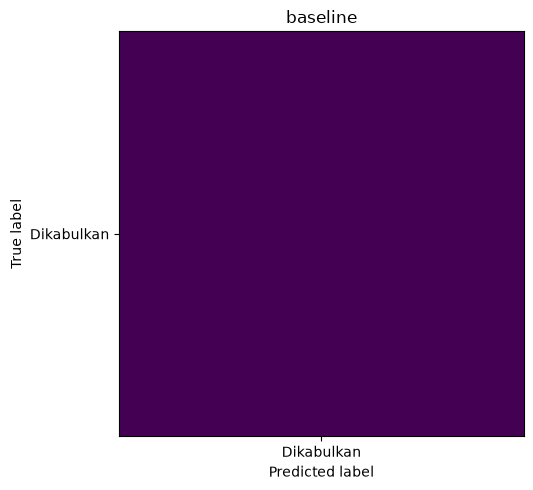

In [14]:
if cm_data:
    n = len(cm_data)
    fig3, axes = plt.subplots(1, n, figsize=(6 * n, 5))
    axes = [axes] if n == 1 else axes
    for ax3, (model_name, (yt, yp)) in zip(axes, cm_data.items()):
        labels = sorted(set(yt) | set(yp))
        cm = confusion_matrix(yt, yp, labels=labels)
        ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=ax3, colorbar=False)
        ax3.set_title(model_name)
    fig3.tight_layout()
    fig3.savefig(os.path.join(PATH_FIGURES_DIR, "confusion_matrix.png"), dpi=150)
    plt.show()
else:
    print("Tidak ada model dengan actual_solution valid -> confusion matrix dilewati.")

## 6. Error Analysis

Mengambil query dengan `f1_at_k` terendah per model, beserta kemungkinan alasan kegagalan retrieval (tanpa ground truth, tidak ada overlap sama sekali, atau overlap parsial dengan presisi/recall rendah).

In [15]:
def error_analysis(df_retrieval, df_pred, top_n=5):
    join_cols = ["query_id", "model_name", "query"] if "query" in df_pred.columns else ["query_id", "model_name"]
    merged = df_retrieval.merge(df_pred[join_cols], on=["query_id", "model_name"], how="left")
    if "query" not in merged.columns:
        merged["query"] = ""

    def reason(row):
        if not row["ground_truth_ids"]:
            return "Tidak ada anotasi ground truth pada queries.json"
        if row["is_success"] == 0:
            return "Tidak ada kasus relevan ter-retrieve dalam Top-K (kemungkinan vocabulary mismatch)"
        if row["f1_at_k"] < 0.5:
            return "Sebagian kasus relevan ter-retrieve namun precision/recall masih rendah"
        return "Performa cukup baik"

    merged["reason"] = merged.apply(reason, axis=1)
    return merged.sort_values("f1_at_k").head(top_n)[
        ["query_id", "model_name", "query", "ground_truth_ids", "retrieved_ids", "f1_at_k", "reason"]
    ]


df_errors = error_analysis(df_retrieval, df_pred, top_n=5)
df_errors

,query_id,model_name,query,ground_truth_ids,retrieved_ids,f1_at_k,reason
1,2,baseline,terjadi perselisihan dan pertengkaran terus me...,[putusan_6071_pdt.g_2022_pa.kab.mlg_2026061708...,[putusan_6071_pdt.g_2022_pa.kab.mlg_2026061708...,0.3333,Sebagian kasus relevan ter-retrieve namun prec...
2,3,baseline,suami meninggalkan rumah dan tidak memberi kabar,[putusan_5210_pdt.g_2022_pa.kab.mlg_2026061708...,[putusan_5210_pdt.g_2022_pa.kab.mlg_2026061708...,0.3333,Sebagian kasus relevan ter-retrieve namun prec...
3,4,baseline,hubungan rumah tangga tidak harmonis,[putusan_5280_pdt.g_2023_pa.kab.mlg_2026061708...,[putusan_5280_pdt.g_2023_pa.kab.mlg_2026061708...,0.3333,Sebagian kasus relevan ter-retrieve namun prec...
4,5,baseline,suami memiliki hubungan dengan perempuan lain,[putusan_1038_pdt.g_2017_pa.kab.mlg_2026061708...,[putusan_1038_pdt.g_2017_pa.kab.mlg_2026061708...,0.3333,Sebagian kasus relevan ter-retrieve namun prec...
6,7,baseline,terjadi kekerasan dalam rumah tangga,[putusan_5657_pdt.g_2020_pa.kab.mlg_2026061708...,[putusan_5657_pdt.g_2020_pa.kab.mlg_2026061708...,0.3333,Sebagian kasus relevan ter-retrieve namun prec...


## 7. Penyimpanan Output

In [16]:
def listcol_to_str(df, cols):
    df = df.copy()
    for c in cols:
        if c in df.columns:
            df[c] = df[c].apply(lambda v: ";".join(v) if isinstance(v, list) else v)
    return df

df_retrieval_out = listcol_to_str(df_retrieval, ["retrieved_ids", "ground_truth_ids"])
df_errors_out = listcol_to_str(df_errors, ["retrieved_ids", "ground_truth_ids"])

df_retrieval_out.to_csv(os.path.join(PATH_EVAL_DIR, "retrieval_metrics.csv"), index=False)
df_summary.to_csv(os.path.join(PATH_EVAL_DIR, "retrieval_summary.csv"), index=False)
df_prediction.to_csv(os.path.join(PATH_EVAL_DIR, "prediction_metrics.csv"), index=False)
df_errors_out.to_csv(os.path.join(PATH_EVAL_DIR, "error_analysis.csv"), index=False)

print("Tersimpan: retrieval_metrics.csv, retrieval_summary.csv, prediction_metrics.csv, error_analysis.csv")

Tersimpan: retrieval_metrics.csv, retrieval_summary.csv, prediction_metrics.csv, error_analysis.csv


## 8. Laporan Markdown Otomatis

In [17]:
def df_to_md_table(df):
    cols = list(df.columns)
    lines = ["| " + " | ".join(cols) + " |", "| " + " | ".join(["---"] * len(cols)) + " |"]
    for _, row in df.iterrows():
        lines.append("| " + " | ".join(str(row[c]) for c in cols) + " |")
    return "\n".join(lines)

best_model = df_summary.iloc[0]
invalid_models = df_prediction[df_prediction["evaluation_mode"] != "Authentic"]["model_name"].tolist()

report = f"""# Laporan Evaluasi Tahap 5 — Retrieval & Prediksi Solusi

## Ringkasan Tujuan Evaluasi
Mengukur performa retrieval Top-{K} dan prediksi solusi sistem CBR menggunakan metrik Accuracy, Precision, Recall, dan F1-score, dibandingkan antar model yang tersedia pada `predictions.csv`.

## Tabel Metrik Retrieval (Rata-Rata per Model)
{df_to_md_table(df_summary)}

## Tabel Metrik Prediksi Solusi (Klasifikasi Berbobot)
{df_to_md_table(df_prediction)}

## Ringkasan Error Analysis (Top {len(df_errors)} F1@K Terendah)
{df_to_md_table(df_errors_out)}

## Kesimpulan
- Model retrieval dengan performa terbaik: **{best_model['model_name']}** (F1@{K} = {best_model['f1_at_k']:.4f}).
- {"Seluruh model memiliki label aktual yang valid untuk evaluasi prediksi." if not invalid_models else f"Model berikut TIDAK memiliki label aktual valid sehingga evaluasi prediksinya tidak sahih: {', '.join(invalid_models)}."}
- Kegagalan retrieval pada beberapa query mengindikasikan potensi *vocabulary mismatch* antara deskripsi query dan diksi hukum formal pada dokumen kasus.
"""

with open(os.path.join(PATH_EVAL_DIR, "evaluation_report.md"), "w", encoding="utf-8") as f:
    f.write(report)

print("Laporan tersimpan di data/eval/evaluation_report.md")

Laporan tersimpan di data/eval/evaluation_report.md
